# TOHR demo

End-to-end run on a large, coarse, flood hazard tile

In [1]:
# Major imports for this notebook.
import logging, os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling

from floodsr.dem_sources.hrdem_mosaic import main_fetch_hrdem_for_lowres_tile
from floodsr.model_registry import fetch_model
from floodsr.tohr import tohr


/opt/conda/envs/dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# Resolve notebook inputs and outputs from environment variables.
PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "/workspace")).resolve()
default_lores_fp = PROJECT_ROOT / "tests/data/wri_aqueduct_yeg/inunriver_historical_000000000WATCH_1980_rp01000.tif"
lores_fp = Path(os.getenv("LORES_FP", str(default_lores_fp))).expanduser().resolve()
assert lores_fp.is_file(), f"missing lores depth tile: {lores_fp}"

# Keep notebook artifacts in one configurable output directory.
out_dir = Path(os.getenv("OUT_DIR", str(PROJECT_ROOT / "_scratch" / "tohr_example"))).expanduser().resolve()
out_dir.mkdir(parents=True, exist_ok=True)
hrdem_cache_dir = Path(os.getenv("HRDEM_CACHE_DIR", str(out_dir / "hrdem_tile_cache"))).expanduser().resolve()
hrdem_cache_dir.mkdir(parents=True, exist_ok=True)
tohr_out_fp = Path(os.getenv("TOHR_OUT_FP", str(out_dir / f"{lores_fp.stem}_tohr.tif"))).expanduser().resolve()
hrdem_fp = Path(os.getenv("HRDEM_FP", str(out_dir / f"{lores_fp.stem}_fetched_hrdem.vrt"))).expanduser().resolve()
reuse_hrdem = os.getenv("REFETCH_HRDEM", "0").strip().lower() not in {"1", "true", "yes"}
dry_depth_thresh_m = float(os.getenv("DRY_DEPTH_THRESH_M", "0.01"))
plot_res_m = float(os.getenv("PLOT_RES_M", "1000.0"))


def _read_plot_raster(raster_fp, *, plot_res_m, resampling=Resampling.nearest):
    """Read one bounded raster view for notebook diagnostics."""
    with rasterio.open(raster_fp) as ds:
        native_shape = (int(ds.height), int(ds.width))
        native_res_xy = (
            abs(float(ds.transform.a)),
            abs(float(ds.transform.e)),
        )
        # Keep geographic rasters on their native grid because their pixel units are degrees, not meters.
        if ds.crs is not None and ds.crs.is_geographic:
            plot_width = native_shape[1]
            plot_height = native_shape[0]
        else:
            plot_width = max(1, int(np.ceil((float(native_shape[1]) * native_res_xy[0]) / plot_res_m)))
            plot_height = max(1, int(np.ceil((float(native_shape[0]) * native_res_xy[1]) / plot_res_m)))
        plot_ar = ds.read(
            1,
            out_shape=(plot_height, plot_width),
            resampling=resampling,
            masked=True,
        )
        profile = ds.profile.copy()
    plot_meta_d = {
        "native_shape": native_shape,
        "native_res_xy": native_res_xy,
        "plot_shape": plot_ar.shape,
        "plot_res_xy": (
            (native_res_xy[0] * float(native_shape[1])) / float(plot_width),
            (native_res_xy[1] * float(native_shape[0])) / float(plot_height),
        ),
    }
    return plot_ar, profile, plot_meta_d


def _plot_hist_and_raster(
    ax_hist,
    ax_img,
    *,
    title,
    arr,
    plot_meta_d,
    cmap,
    is_depth,
    dry_depth_thresh_m,
    depth_vmax=None,
):
    """Plot one histogram and image pair from one bounded array."""
    vals = arr.compressed()
    assert vals.size > 0, f"no valid values found for {title}"
    show_arr = np.ma.masked_where(arr.filled(0.0) < dry_depth_thresh_m, arr) if is_depth else arr

    ax_hist.hist(vals, bins=60, color="steelblue", alpha=0.9)
    if is_depth:
        ax_hist.axvline(dry_depth_thresh_m, color="red", linestyle="--", linewidth=1.5)
        ax_hist.set_xlabel("Depth (m)")
    else:
        ax_hist.set_xlabel("Elevation (m)")
    ax_hist.set_ylabel("Count")
    ax_hist.set_title(f"{title} histogram")
    ax_hist.grid(color="lightgrey", linestyle="-", linewidth=0.7)
    ax_hist.text(
        0.98,
        0.95,
        chr(10).join([
            f"native shape: {plot_meta_d['native_shape']}",
            f"native res(x,y): ({plot_meta_d['native_res_xy'][0]:.6g}, {plot_meta_d['native_res_xy'][1]:.6g})",
            f"plot shape: {plot_meta_d['plot_shape']}",
            f"plot res(x,y): ({plot_meta_d['plot_res_xy'][0]:.6g}, {plot_meta_d['plot_res_xy'][1]:.6g})",
            f"min: {vals.min():.3f}",
            f"max: {vals.max():.3f}",
            f"mean: {vals.mean():.3f}",
            f"std: {vals.std():.3f}",
        ]),
        transform=ax_hist.transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
    )

    if is_depth:
        im = ax_img.imshow(show_arr, cmap=cmap, vmin=0.0, vmax=depth_vmax)
        cbar_label = "Depth (m)"
    else:
        im = ax_img.imshow(show_arr, cmap=cmap)
        cbar_label = "Elevation (m)"
    ax_img.set_title(f"{title} raster")
    ax_img.set_axis_off()
    plt.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04, label=cbar_label)

    return vals

print(f"out_dir:\n    {out_dir}")
print(f"lores_fp:\n    {lores_fp}")
print(f"hrdem_fp:\n    {hrdem_fp}")
print(f"hrdem_cache_dir:\n    {hrdem_cache_dir}")
print(f"tohr_out_fp:\n    {tohr_out_fp}")
print(f"reuse_hrdem:\n    {reuse_hrdem}")
print(f"plot_res_m:\n    {plot_res_m}")


out_dir:
    /workspace/_scratch/tohr_example
lores_fp:
    /workspace/tests/data/wri_aqueduct_yeg/inunriver_historical_000000000WATCH_1980_rp01000.tif
hrdem_fp:
    /workspace/_scratch/tohr_example/inunriver_historical_000000000WATCH_1980_rp01000_fetched_hrdem.vrt
tohr_out_fp:
    /workspace/_scratch/tohr_example/inunriver_historical_000000000WATCH_1980_rp01000_tohr.tif
reuse_hrdem:
    True
plot_res_m:
    1000.0


## plot raw lores depth

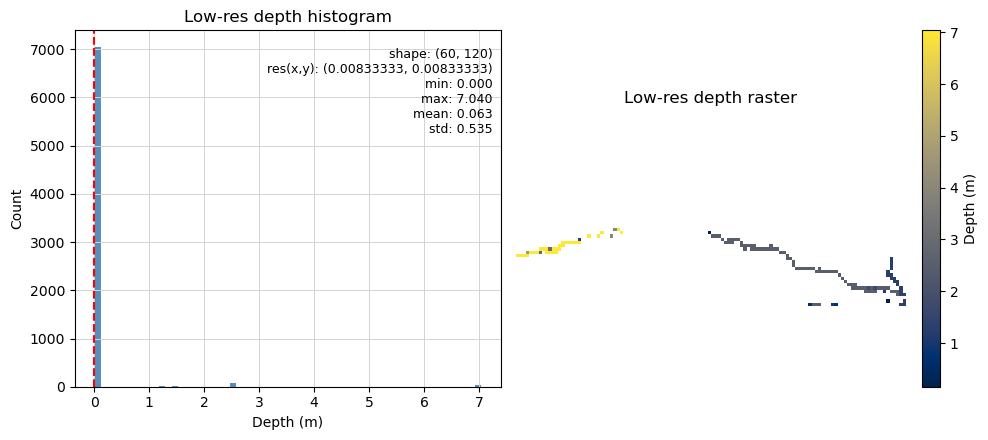

In [3]:
# Plot the raw low-resolution depth raster with histogram and imshow diagnostics.
with rasterio.open(lores_fp) as ds_lores:
    lores_plot_ar = ds_lores.read(1, masked=True)
    lores_plot_profile = ds_lores.profile

lores_plot_vals = lores_plot_ar.compressed()
assert lores_plot_vals.size > 0, f"no valid lores depth values found in {lores_fp}"
lores_res_xy = (
    abs(float(lores_plot_profile["transform"].a)),
    abs(float(lores_plot_profile["transform"].e)),
)
lores_plot_show_ar = np.ma.masked_where(lores_plot_ar.filled(0.0) < dry_depth_thresh_m, lores_plot_ar)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].hist(lores_plot_vals, bins=60, color="steelblue", alpha=0.9)
axes[0].axvline(dry_depth_thresh_m, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Low-res depth histogram")
axes[0].set_xlabel("Depth (m)")
axes[0].set_ylabel("Count")
axes[0].grid(color="lightgrey", linestyle="-", linewidth=0.7)
axes[0].text(
    0.98,
    0.95,
    chr(10).join([
        f"shape: {lores_plot_ar.shape}",
        f"res(x,y): ({lores_res_xy[0]:.6g}, {lores_res_xy[1]:.6g})",
        f"min: {lores_plot_vals.min():.3f}",
        f"max: {lores_plot_vals.max():.3f}",
        f"mean: {lores_plot_vals.mean():.3f}",
        f"std: {lores_plot_vals.std():.3f}",
    ]),
    transform=axes[0].transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="right",
)

im = axes[1].imshow(lores_plot_show_ar, cmap="cividis")
axes[1].set_title("Low-res depth raster")
axes[1].set_axis_off()
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Depth (m)")

plt.tight_layout()
plt.show()


# FETCH HRDEM

In [4]:
# Run floodsr via the Python bindings with verbose logs and HRDEM fetch progress.
logging.basicConfig(level=logging.INFO, force=True)
logger = logging.getLogger("tohr")
model_version = "ResUNet_16x_DEM"


In [5]:

print(f"running floodsr Python API for {model_version}")
 

 
if reuse_hrdem and hrdem_fp.is_file():
    print(f"reusing existing HRDEM:\n    {hrdem_fp}")
else:
    fetch_result = main_fetch_hrdem_for_lowres_tile(
        depth_lr_fp=lores_fp,
        output_fp=hrdem_fp,
        cache_dir=hrdem_cache_dir,
        force_tiling=True,
        show_progress=True,
        logger=logger,
        use_cache=True,
    )
    hrdem_fp = Path(fetch_result.dem_fp).expanduser().resolve()

assert hrdem_fp.is_file(), f"missing HRDEM output: {hrdem_fp}"


running floodsr Python API for ResUNet_16x_DEM
reusing existing HRDEM:
    /workspace/_scratch/tohr_example/inunriver_historical_000000000WATCH_1980_rp01000_fetched_hrdem.vrt


# Plot the fetched HRDEM

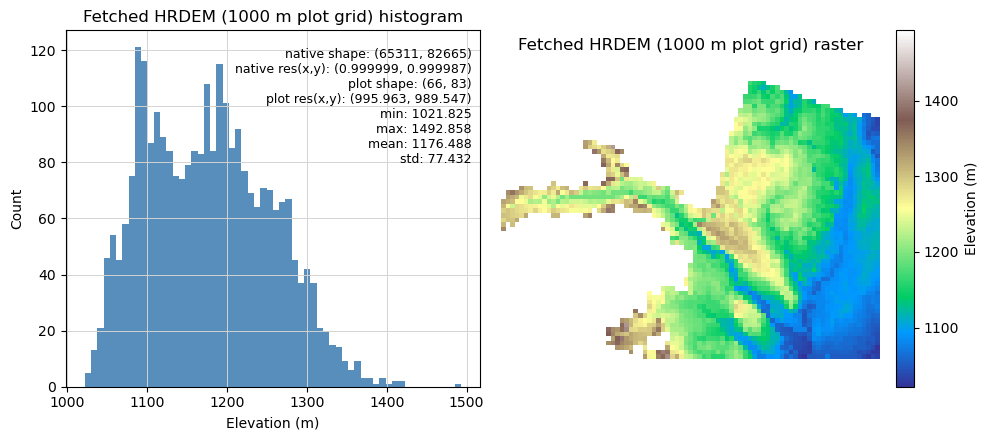

In [6]:
# Plot the fetched HRDEM from one bounded read so diagnostics stay memory safe.
dem_plot_ar, _, dem_plot_meta_d = _read_plot_raster(hrdem_fp, plot_res_m=plot_res_m, resampling=Resampling.nearest)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
_plot_hist_and_raster(
    axes[0],
    axes[1],
    title=f"Fetched HRDEM ({plot_res_m:.0f} m plot grid)",
    arr=dem_plot_ar,
    plot_meta_d=dem_plot_meta_d,
    cmap="terrain",
    is_depth=False,
    dry_depth_thresh_m=dry_depth_thresh_m,
)

fig.tight_layout()
plt.show()


# TOHR

In [7]:

# Run the ToHR model from the fetched HRDEM raster.
model_fp = fetch_model(model_version)
print(f"fetched model:\n    {model_fp}")

fetched model:
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx


In [8]:


result = tohr(
    model_version=model_version,
    model_fp=model_fp,
    depth_lr_fp=lores_fp,
    dem_hr_fp=hrdem_fp,
    output_fp=tohr_out_fp,
    max_depth=10,
    window_method="hard",
    tile_overlap=0,
    show_progress=True,
    logger=logger,
    crs_policy="use-dem",
)
tohr_out_fp = Path(result["output_fp"]).expanduser().resolve()
tohr_ok = tohr_out_fp.is_file() and hrdem_fp.is_file()

assert tohr_ok, f"missing output(s): tohr={tohr_out_fp.is_file()}, hrdem={hrdem_fp.is_file()}"


INFO:tohr:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16
INFO:tohr:tohr path selection
  requested_window_method=hard
  dem_float32_bytes=21,595,735,260
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=windowed
    depth=EPSG:4326
    dem=EPSG:3979
    target=EPSG:3979
INFO:tohr:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-platform-prep-wt4n8fa1/inunriver_historical_000000000WATCH_1980_rp01000_platform_depth.tif
platform_dem_hr
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-platform-prep-wt4n8fa1/inunriver_historical_000000000WATCH_1980_rp01000_fetched_hrdem_platform_dem.tif
output
    /workspace/_scratch/tohr_example/inunriver_historical_000000000WATCH_1980_rp01000_tohr.tif
INFO:tohr:platform-preprocessed inputs
  depth_lr shape=(60, 120) res=(688.8743025149432, 1225.03372

### plot result

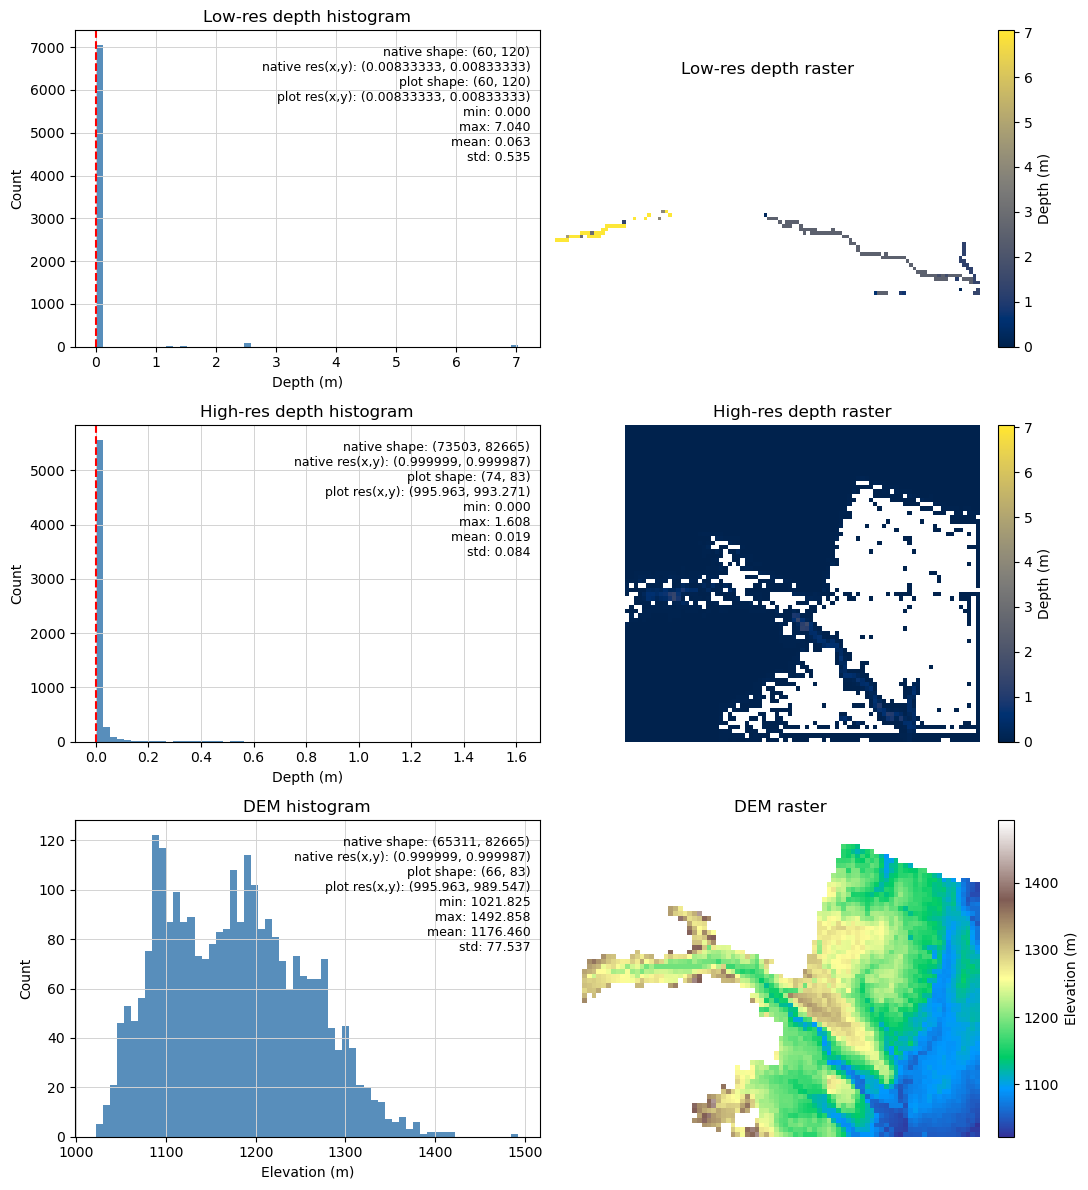

In [9]:
# Plot all diagnostics from bounded reads so the notebook never materializes the full 23 GB output.
lores_result_ar, _, lores_result_meta_d = _read_plot_raster(lores_fp, plot_res_m=plot_res_m, resampling=Resampling.nearest)
hires_result_ar, _, hires_result_meta_d = _read_plot_raster(tohr_out_fp, plot_res_m=plot_res_m, resampling=Resampling.nearest)
dem_result_ar, _, dem_result_meta_d = _read_plot_raster(hrdem_fp, plot_res_m=plot_res_m, resampling=Resampling.nearest)

depth_vmax = max(float(lores_result_ar.compressed().max()), float(hires_result_ar.compressed().max()))
rows = [
    ("Low-res depth", lores_result_ar, lores_result_meta_d, "cividis", True),
    ("High-res depth", hires_result_ar, hires_result_meta_d, "cividis", True),
    ("DEM", dem_result_ar, dem_result_meta_d, "terrain", False),
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(11, 12))

for row_idx, (title, arr, plot_meta_d, cmap, is_depth) in enumerate(rows):
    _plot_hist_and_raster(
        axes[row_idx, 0],
        axes[row_idx, 1],
        title=title,
        arr=arr,
        plot_meta_d=plot_meta_d,
        cmap=cmap,
        is_depth=is_depth,
        dry_depth_thresh_m=dry_depth_thresh_m,
        depth_vmax=depth_vmax,
    )

plt.tight_layout()
plt.show()
